Arquitetura do Modelo (CNN 3D)
No notebook anterior, a gente construiu um LunaDataset que entrega cubos 3D de tomografia no formato [1, 32, 48, 48] -- um canal, 32 fatias de profundidade, 48x48 pixels por fatia. Agora a gente precisa construir a rede neural que vai olhar pra esses cubos e decidir: isso e um nodulo ou nao?

A ideia e usar uma CNN 3D -- a mesma logica de convolucoes que a gente ja conhece de imagens 2D, mas com uma dimensao a mais. Em vez de filtros quadrados deslizando sobre uma imagem plana, os filtros agora sao cubos que deslizam sobre o volume inteiro.

In [1]:
import torch
from torch import nn


De Conv2D para Conv3D
Se voce ja trabalhou com CNNs em imagens, a transicao pra 3D e bem natural. Pensa assim: no 2D, o filtro e como um carimbo quadrado que vai deslizando pela imagem, calculando uma soma ponderada em cada posicao. No 3D, imagina um cubo de gelatina passando pelo volume -- em vez de deslizar em duas direcoes (altura e largura), ele desliza em tres (profundidade, altura e largura).

A tabela abaixo resume as diferencas:

Conv2D	Conv3D
Input	[batch, canais, H, W]	[batch, canais, D, H, W]
Filtro	quadrado (ex: 3x3)	cubo (ex: 3x3x3)
Operacao	desliza em 2 eixos	desliza em 3 eixos
Params por filtro	C_in * k * k	C_in * k * k * k
Uso tipico	fotos, imagens 2D	volumes, videos, CTs
Repare que um filtro 3x3x3 tem 27 posicoes, contra 9 de um filtro 3x3. Sao mais parametros por filtro, mas a gente compensa usando poucos canais no inicio da rede.

In [2]:
conv2d = nn.Conv2d(1, 8, kernel_size=3, padding=1)
conv3d = nn.Conv3d(1, 8, kernel_size=3, padding=1)

print(f"Conv2D weight shape: {conv2d.weight.shape}")
print(f"Conv3D weight shape: {conv3d.weight.shape}")
print(f"\nConv2D params por filtro: {1 * 3 * 3} = 9")
print(f"Conv3D params por filtro: {1 * 3 * 3 * 3} = 27")

Conv2D weight shape: torch.Size([8, 1, 3, 3])
Conv3D weight shape: torch.Size([8, 1, 3, 3, 3])

Conv2D params por filtro: 9 = 9
Conv3D params por filtro: 27 = 27


In [5]:
x_3d = torch.randn(1, 1, 32, 48, 48)
out_3d = conv3d(x_3d)

print(f"Input:  {x_3d.shape}")
print(f"Output: {out_3d.shape}")
print(f"\nCom padding=1, as dimensoes espaciais se mantem (32, 48, 48)")
print(f"So os canais mudaram: 1 -> 8")

Input:  torch.Size([1, 1, 32, 48, 48])
Output: torch.Size([1, 8, 32, 48, 48])

Com padding=1, as dimensoes espaciais se mantem (32, 48, 48)
So os canais mudaram: 1 -> 8


MaxPool3D
Depois de cada par de convolucoes, a gente aplica um MaxPool3d(2, 2). A ideia e a mesma do 2D: dividir o volume em blocos de 2x2x2 e manter so o maior valor de cada bloco. Como o bloco tem tamanho 2 em cada eixo, todas as dimensoes espaciais caem pela metade.

Pensa num cubo de Rubik: cada grupo de 2x2x2 cubinhos (8 no total) vira um so cubinho -- o que tinha o maior valor.

In [4]:
pool = nn.MaxPool3d(2, 2)
x = torch.randn(1, 8, 32, 48, 48)
out = pool(x)

print(f"Input:  {x.shape}")
print(f"Output: {out.shape}")
print(f"\nCada dimensao caiu pela metade: 32->16, 48->24, 48->24")

Input:  torch.Size([1, 8, 32, 48, 48])
Output: torch.Size([1, 8, 16, 24, 24])

Cada dimensao caiu pela metade: 32->16, 48->24, 48->24


O bloco basico: LunaBlock
Agora a gente pode montar o bloco basico da rede. Cada LunaBlock segue o padrao:

Conv3D -> ReLU -> Conv3D -> ReLU -> MaxPool3D
Por que duas convolucoes em sequencia antes do pooling? Cada convolucao 3x3x3 "enxerga" uma vizinhanca de 3x3x3 voxels. Quando a gente empilha duas, a segunda convolucao enxerga a vizinhanca da primeira -- entao o campo de visao (receptive field) efetivo cresce pra 5x5x5, sem precisar de filtros maiores. Esse padrao vem la da VGGNet, uma das primeiras arquiteturas a mostrar que varias convs pequenas sao melhores que uma conv grande.

Na primeira convolucao do bloco, a gente muda o numero de canais (ex: de 1 pra 8). Na segunda, mantemos os canais fixos (8 pra 8). A primeira conv "expande" a representacao, a segunda "refina".

In [6]:
class LunaBlock(nn.Module):
    def __init__(self, in_channels, conv_channels):
        super().__init__()
        self.conv1 = nn.Conv3d(
            in_channels, conv_channels,
            kernel_size=3, padding=1, bias=True,
        )
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv3d(
            conv_channels, conv_channels,
            kernel_size=3, padding=1, bias=True,
        )
        self.relu2 = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool3d(2, 2)

    def forward(self, x):
        out = self.conv1(x)
        out = self.relu1(out)
        out = self.conv2(out)
        out = self.relu2(out)
        return self.maxpool(out)

In [7]:
block = LunaBlock(in_channels=1, conv_channels=8)
x = torch.randn(2, 1, 32, 48, 48)
out = block(x)

print(f"Input:  {x.shape}")
print(f"Output: {out.shape}")
print(f"\nCanais: 1 -> 8")
print(f"Espacial: 32x48x48 -> 16x24x24 (metade em cada eixo)")

Input:  torch.Size([2, 1, 32, 48, 48])
Output: torch.Size([2, 8, 16, 24, 24])

Canais: 1 -> 8
Espacial: 32x48x48 -> 16x24x24 (metade em cada eixo)


Conceitos antes de montar o modelo
Antes de juntar os blocos no modelo completo, vale entender quatro decisoes de design.

BatchNorm na entrada
Os valores de Hounsfield que vem do CT variam de -1000 a +1000 -- uma faixa enorme. Redes neurais convergem melhor quando os inputs estao numa faixa mais comportada (perto de media zero, variancia um). O BatchNorm3d faz exatamente isso: normaliza os valores de cada batch pra ter media zero e variancia um, e depois aprende dois parametros (gamma e beta) que ajustam a escala e o deslocamento ideal. E como dar um "banho" nos dados antes de entrar na rede.

De onde vem o 1152?
Esse numero nao e magico -- e consequencia direta da arquitetura. A cada bloco, o MaxPool divide as dimensoes espaciais por 2 e as convolucoes dobram os canais. Veja a progressao:

Camada	Shape	Descricao
Input	[B, 1, 32, 48, 48]	Crop 3D do CT
BatchNorm	[B, 1, 32, 48, 48]	Normaliza, mesma shape
Bloco 1 (1 -> 8)	[B, 8, 16, 24, 24]	Canais x8, espacial /2
Bloco 2 (8 -> 16)	[B, 16, 8, 12, 12]	Canais x2, espacial /2
Bloco 3 (16 -> 32)	[B, 32, 4, 6, 6]	Canais x2, espacial /2
Bloco 4 (32 -> 64)	[B, 64, 2, 3, 3]	Canais x2, espacial /2
Flatten	[B, 1152]	64 * 2 * 3 * 3 = 1152
Linear	[B, 2]	2 classes

Repare como as dimensoes espaciais (32, 48, 48) vao sendo comprimidas a cada bloco, enquanto os canais vao crescendo. No final, toda a informacao espacial foi condensada em 1152 features que alimentam a camada linear.

Saida dupla: logits e probabilidades
O nosso modelo vai retornar duas coisas: logits e probs.

Logits sao os valores crus que saem da camada linear -- podem ser qualquer numero, positivo ou negativo. Sao esses valores que o CrossEntropyLoss espera (ele ja aplica softmax internamente, entao nao pode receber probabilidades).

Probabilidades sao os logits passados pelo Softmax, que transforma qualquer par de numeros em dois valores entre 0 e 1 que somam 1. Assim a gente consegue interpretar: "70% de chance de ser nodulo" faz sentido pra um humano, "logit 1.2" nao faz.

Na pratica: logits pro treino, probabilidades pra interpretacao.

Inicializacao Kaiming
Quando a gente cria uma rede neural, os pesos comecam com valores aleatorios. Mas nem qualquer valor aleatorio serve -- se os pesos forem grandes demais, o sinal "explode" passando pelas camadas; se forem pequenos demais, o sinal "morre".

A inicializacao Kaiming (tambem chamada de He initialization) calibra a variancia dos pesos levando em conta que a gente usa ReLU como ativacao. O ReLU zera metade dos valores (os negativos), entao os pesos precisam ser um pouco maiores pra compensar. O resultado e que o sinal se mantem estavel conforme passa pelas camadas, evitando gradientes que explodem ou desaparecem.

Montando o LunaModel
Agora sim, vamos juntar tudo. A arquitetura completa fica assim:

Input [B, 1, 32, 48, 48]
    |
    v
BatchNorm3d(1)          -- normaliza os valores HU
    |
    v
LunaBlock(1 -> 8)       -- [B, 8, 16, 24, 24]
    |
    v
LunaBlock(8 -> 16)      -- [B, 16, 8, 12, 12]
    |
    v
LunaBlock(16 -> 32)     -- [B, 32, 4, 6, 6]
    |
    v
LunaBlock(32 -> 64)     -- [B, 64, 2, 3, 3]
    |
    v
Flatten                  -- [B, 1152]
    |
    v
Linear(1152, 2)          -- [B, 2]
    |
    v
Softmax(dim=1)           -- [B, 2] probabilidades



In [8]:
import math

class LunaModel(nn.Module):
    def __init__(self, in_channels=1, conv_channels=8):
        super().__init__()
        self.tail_batchnorm = nn.BatchNorm3d(1)
        self.block1 = LunaBlock(in_channels, conv_channels)
        self.block2 = LunaBlock(conv_channels, conv_channels * 2)
        self.block3 = LunaBlock(conv_channels * 2, conv_channels * 4)
        self.block4 = LunaBlock(conv_channels * 4, conv_channels * 8)
        self.head_linear = nn.Linear(1152, 2)
        self.head_softmax = nn.Softmax(dim=1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if type(m) in {nn.Linear, nn.Conv3d}:
                nn.init.kaiming_normal_(
                    m.weight.data, a=0,
                    mode="fan_out", nonlinearity="relu",
                )
                if m.bias is not None:
                    fan_in, fan_out = \
                        nn.init._calculate_fan_in_and_fan_out(m.weight.data)
                    bound = 1 / math.sqrt(fan_out)
                    nn.init.normal_(m.bias, -bound, bound)

    def forward(self, x):
        out = self.tail_batchnorm(x)
        out = self.block1(out)
        out = self.block2(out)
        out = self.block3(out)
        out = self.block4(out)
        out = out.view(out.size(0), -1)
        logits = self.head_linear(out)
        probs = self.head_softmax(logits)
        return logits, probs

Verificando as shapes
Vamos conferir que o modelo produz o output esperado. Vou criar um tensor falso com a mesma shape que o LunaDataset entrega e passar pelo modelo:

In [9]:
model = LunaModel()
x = torch.randn(2, 1, 32, 48, 48)
logits, probs = model(x)

print(f"Input:  {x.shape}")
print(f"Logits: {logits.shape}")
print(f"Probs:  {probs.shape}")
print(f"\nProbs somam 1? {probs.sum(dim=1)}")

Input:  torch.Size([2, 1, 32, 48, 48])
Logits: torch.Size([2, 2])
Probs:  torch.Size([2, 2])

Probs somam 1? tensor([1., 1.], grad_fn=<SumBackward1>)


Agora vamos rastrear o tensor camada por camada pra confirmar que a tabela de dimensoes que a gente montou antes esta correta:

In [10]:
x = torch.randn(2, 1, 32, 48, 48)
print(f"Input:            {x.shape}")

out = model.tail_batchnorm(x)
print(f"BatchNorm:        {out.shape}")

out = model.block1(out)
print(f"Bloco 1 (1->8):   {out.shape}")

out = model.block2(out)
print(f"Bloco 2 (8->16):  {out.shape}")

out = model.block3(out)
print(f"Bloco 3 (16->32): {out.shape}")

out = model.block4(out)
print(f"Bloco 4 (32->64): {out.shape}")

out = out.view(out.size(0), -1)
print(f"Flatten:          {out.shape}")

logits = model.head_linear(out)
print(f"Linear:           {logits.shape}")

Input:            torch.Size([2, 1, 32, 48, 48])
BatchNorm:        torch.Size([2, 1, 32, 48, 48])
Bloco 1 (1->8):   torch.Size([2, 8, 16, 24, 24])
Bloco 2 (8->16):  torch.Size([2, 16, 8, 12, 12])
Bloco 3 (16->32): torch.Size([2, 32, 4, 6, 6])
Bloco 4 (32->64): torch.Size([2, 64, 2, 3, 3])
Flatten:          torch.Size([2, 1152])
Linear:           torch.Size([2, 2])


Contando parametros
Quantos parametros treinaveis esse modelo tem? Essa e uma pergunta importante pra ter nocao da complexidade da rede:

In [11]:
total = sum(p.numel() for p in model.parameters())
treinaveis = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total de parametros: {total:,}")
print(f"Treinaveis: {treinaveis:,}")

Total de parametros: 222,220
Treinaveis: 222,220


Pra ter uma referencia: a ResNet-18 (uma das menores ResNets) tem ~11 milhoes de parametros. O nosso modelo e uma fracao disso. Faz sentido -- nossa tarefa e relativamente simples (classificar crops pequenos de 32x48x48 em duas classes) e nao precisa de uma rede gigante. Rede menor tambem e mais rapida pra treinar e menos propensa a overfitting.

Vamos ver como esses parametros se distribuem pelas camadas:

In [12]:
for name, param in model.named_parameters():
    print(f"{name:40s} {str(list(param.shape)):20s} {param.numel():>8,}")

tail_batchnorm.weight                    [1]                         1
tail_batchnorm.bias                      [1]                         1
block1.conv1.weight                      [8, 1, 3, 3, 3]           216
block1.conv1.bias                        [8]                         8
block1.conv2.weight                      [8, 8, 3, 3, 3]         1,728
block1.conv2.bias                        [8]                         8
block2.conv1.weight                      [16, 8, 3, 3, 3]        3,456
block2.conv1.bias                        [16]                       16
block2.conv2.weight                      [16, 16, 3, 3, 3]       6,912
block2.conv2.bias                        [16]                       16
block3.conv1.weight                      [32, 16, 3, 3, 3]      13,824
block3.conv1.bias                        [32]                       32
block3.conv2.weight                      [32, 32, 3, 3, 3]      27,648
block3.conv2.bias                        [32]                       32
block4

Testando com dados reais
A gente construiu o modelo e verificou as shapes com tensores aleatorios. Agora vamos usar dados de verdade pra garantir que tudo funciona de ponta a ponta:

In [13]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../src")))
from luna_data import LunaDataset

ds = LunaDataset()
n_nod = sum(1 for c in ds.candidates if c.is_nodule)
print(f"Dataset: {len(ds)} candidatos")
print(f"Nodulos: {n_nod}")

Dataset: 551065 candidatos
Nodulos: 1351


In [14]:
samples = []
for i in list(range(4)) + list(range(n_nod, n_nod + 4)):
    samples.append(ds[i])

crops = torch.stack([s[0] for s in samples])
labels = torch.stack([s[1] for s in samples])

model.eval()
with torch.no_grad():
    logits, probs = model(crops)

for i in range(8):
    label = "nodulo" if labels[i][1] == 1 else "nao-nodulo"
    prob_nod = probs[i][1].item()
    print(f"  {label:12s} -> prob nodulo: {prob_nod:.3f}")

  nodulo       -> prob nodulo: 0.000
  nodulo       -> prob nodulo: 0.000
  nodulo       -> prob nodulo: 0.000
  nodulo       -> prob nodulo: 0.000
  nao-nodulo   -> prob nodulo: 0.000
  nao-nodulo   -> prob nodulo: 0.000
  nao-nodulo   -> prob nodulo: 0.000
  nao-nodulo   -> prob nodulo: 0.000


Repare que as probabilidades estao todas em 0.00 -- o modelo esta "chutando" tudo como nao-nodulo. Isso e normal: com a inicializacao Kaiming e a softmax, os pesos aleatorios podem criar um vies forte pra uma das classes. O modelo ainda nao foi treinado, entao ele nao sabe distinguir nada.

Vamos confirmar olhando a probabilidade media de "nodulo" no batch:

In [15]:
prob_media = probs[:, 1].mean().item()
print(f"Probabilidade media de nodulo: {prob_media:.4f}")
print(f"Modelo nao treinado: vies da inicializacao aleatoria")

Probabilidade media de nodulo: 0.0000
Modelo nao treinado: vies da inicializacao aleatoria


Vamos visualizar alguns crops junto com a predicao do modelo. Linha de cima: nodulos. Linha de baixo: nao-nodulos.

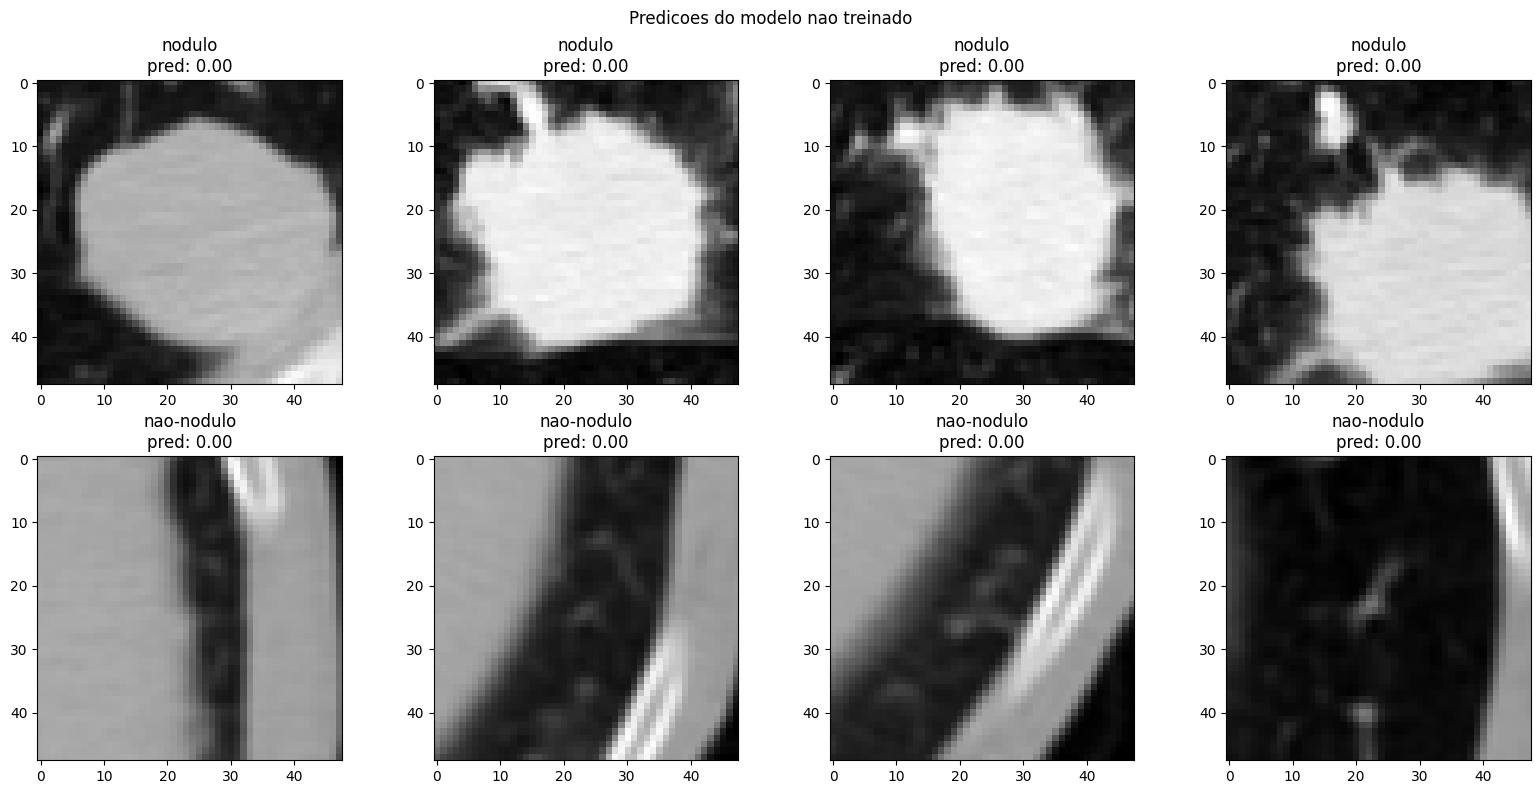

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(8):
    row, col = i // 4, i % 4
    axes[row, col].imshow(crops[i, 0, 16], cmap="gray")
    label = "nodulo" if labels[i][1] == 1 else "nao-nodulo"
    prob = probs[i][1].item()
    axes[row, col].set_title(f"{label}\npred: {prob:.2f}")
plt.suptitle("Predicoes do modelo nao treinado")
plt.tight_layout()
plt.show()

Exportando o modulo
Agora a gente exporta o LunaBlock e o LunaModel pro arquivo src/model.py, pra poder importar nos proximos notebooks:

In [18]:
%%writefile ../src/model.py
"""Modelo de classificacao de nodulos pulmonares (CNN 3D)."""

import math

from torch import nn


class LunaBlock(nn.Module):
    def __init__(self, in_channels, conv_channels):
        super().__init__()
        self.conv1 = nn.Conv3d(
            in_channels, conv_channels,
            kernel_size=3, padding=1, bias=True,
        )
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv3d(
            conv_channels, conv_channels,
            kernel_size=3, padding=1, bias=True,
        )
        self.relu2 = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool3d(2, 2)

    def forward(self, x):
        out = self.conv1(x)
        out = self.relu1(out)
        out = self.conv2(out)
        out = self.relu2(out)
        return self.maxpool(out)


class LunaModel(nn.Module):
    def __init__(self, in_channels=1, conv_channels=8):
        super().__init__()
        self.tail_batchnorm = nn.BatchNorm3d(1)
        self.block1 = LunaBlock(in_channels, conv_channels)
        self.block2 = LunaBlock(conv_channels, conv_channels * 2)
        self.block3 = LunaBlock(conv_channels * 2, conv_channels * 4)
        self.block4 = LunaBlock(conv_channels * 4, conv_channels * 8)
        self.head_linear = nn.Linear(1152, 2)
        self.head_softmax = nn.Softmax(dim=1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if type(m) in {nn.Linear, nn.Conv3d}:
                nn.init.kaiming_normal_(
                    m.weight.data, a=0,
                    mode="fan_out", nonlinearity="relu",
                )
                if m.bias is not None:
                    fan_in, fan_out = \
                        nn.init._calculate_fan_in_and_fan_out(m.weight.data)
                    bound = 1 / math.sqrt(fan_out)
                    nn.init.normal_(m.bias, -bound, bound)

    def forward(self, x):
        out = self.tail_batchnorm(x)
        out = self.block1(out)
        out = self.block2(out)
        out = self.block3(out)
        out = self.block4(out)
        out = out.view(out.size(0), -1)
        logits = self.head_linear(out)
        probs = self.head_softmax(logits)
        return logits, probs

Overwriting ../src/model.py


Pra confirmar que o import funciona, reinicie o kernel e rode a celula abaixo:

In [19]:
import sys
from pathlib import Path
import torch

sys.path.insert(0, str(Path("../src")))
from model import LunaModel

model = LunaModel()
x = torch.randn(1, 1, 32, 48, 48)
logits, probs = model(x)
print(f"Output shape: {logits.shape}")
print(f"Probs somam 1: {probs.sum().item():.4f}")

Output shape: torch.Size([1, 2])
Probs somam 1: 1.0000


Proximo passo
O modelo esta pronto, mas ainda nao sabe nada -- as predicoes sao puro chute. No proximo notebook, a gente vai treinar esse modelo: definir a funcao de perda (CrossEntropyLoss), lidar com o desbalanceamento brutal entre as classes (1351 nodulos vs 549k nao-nodulos), aplicar data augmentation 3D e acompanhar as metricas ao longo do treino.